# 04 – CNN baseline (MNIST / Kaggle Digit Recognizer)

Convolutional neural network baseline for the Kaggle digit-recognizer dataset.

 - Load and inspect the training data
 - Reshape flat 784‑dim vectors to 1×28×28 images
- Train a small CNN with two conv layers and max-pooling
- Evaluate accuracy on a 20% validation split
- Generate a Kaggle submission from the trained model`

In [3]:
import os
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


(42000, 785)
Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8'],
      dtype='object')


<Axes: xlabel='label', ylabel='count'>

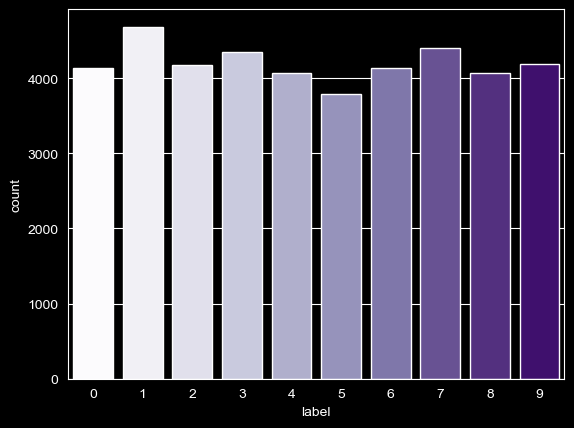

In [4]:
df = pd.read_csv("data/train.csv")
print(df.shape)
print(df.columns[:10])
sns.countplot(
    data=df,
    x='label',
    hue='label',
    palette='Purples',
    legend=False
)


In [5]:
y = df['label']
X = df.drop(columns=['label'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## CNN baseline and training

We define a small convolutional neural network for 28×28 grayscale digit images: two 3×3 conv layers (1→32→64 channels) with ReLU activations and a 2×2 max-pooling layer, followed by a fully connected head (64×14×14 → 128 → 10). The flat 784‑dim feature vectors are reshaped to (batch, 1, 28, 28), and the model is trained for 10 epochs using cross-entropy loss and the Adam optimizer with mini-batches of size 64.


In [8]:
import torch.nn.functional as F

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # input: (batch, 1, 28, 28)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # -> (32, 28, 28)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # -> (64, 28, 28)
        self.pool  = nn.MaxPool2d(2, 2)                           # -> (64, 14, 14)
        self.fc1   = nn.Linear(64 * 14 * 14, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))        # (B,32,28,28)
        x = self.pool(F.relu(self.conv2(x)))  # (B,64,14,14)
        x = x.view(x.size(0), -1)        # flatten to (B, 64*14*14)
        x = F.relu(self.fc1(x))          # (B,128)
        x = self.fc2(x)                  # (B,10) logits
        return x

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).view(-1, 1, 28, 28)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).view(-1, 1, 28, 28)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)


model = CNN()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

print(X_train_tensor.shape)  # expect roughly (33600, 1, 28, 28)


for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{num_epochs} done")


torch.Size([33600, 1, 28, 28])
Epoch 1/10 done
Epoch 2/10 done
Epoch 3/10 done
Epoch 4/10 done
Epoch 5/10 done
Epoch 6/10 done
Epoch 7/10 done
Epoch 8/10 done
Epoch 9/10 done
Epoch 10/10 done


In [10]:
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    preds = logits.argmax(dim=1)
    acc = (preds == y_test_tensor).float().mean().item()
    print("CNN test accuracy:", acc)


CNN test accuracy: 0.9864285588264465


In [11]:
test_df = pd.read_csv("data/test.csv")
X_kaggle = (test_df / 255.0).values
X_kaggle_tensor = torch.tensor(X_kaggle, dtype=torch.float32).view(-1, 1, 28, 28)

model.eval()
with torch.no_grad():
    logits = model(X_kaggle_tensor)
    preds = logits.argmax(dim=1).cpu().numpy()

submission = pd.DataFrame({
    "ImageId": np.arange(1, len(preds) + 1),
    "Label": preds
})
os.makedirs("submissions/CNN-baseline", exist_ok=True)
submission.to_csv("submissions/CNN-baseline/submission.csv", index=False)
